In [2]:
%load_ext autoreload
%autoreload 2
import sys
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from os.path import join

config_dir = "../../config"
if config_dir not in sys.path:
    sys.path.insert(0, config_dir)

from config import add_to_path, root_dir, google_folder_id, download_dir
add_to_path(join(root_dir, 'src'))
import utils.visualization as visualisation
import utils.preprocessing as preprocessing
from data_loader import load_data

Added to sys: c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\Projet-recheche-INSA-anomaly-detection-librairy-1\src


In [3]:
data_dict, extracted_dir = load_data(
    file_id=google_folder_id,
    work_dir=join(download_dir, "gdrive_tar_data"),
    tar_name="data.tar",
    pattern="*.csv",
)

list_keys = list(data_dict.keys())
#df = data_dict[list_keys[11]]
#df = preprocessing.clean_dataframe(df)


Extracted data found at: c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24
Loading ARAG data from: c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24


In [4]:
import os


# 1. On liste les clés originales (les chemins complets)
all_paths = list(data_dict.keys())

# 3. On crée le nouveau dictionnaire avec des clés propres
selected_sessions = {}
temp_list = []

for path, df in data_dict.items():
        # On extrait juste le nom du fichier
        clean_name = os.path.splitext(os.path.basename(path))[0]
        selected_sessions[clean_name] = df
        df_cleaned = preprocessing.clean_dataframe(df.copy())
        
        # C. Ajout de l'identifiant de session
        df_cleaned['session_id'] = clean_name
        
        # D. Stockage
        selected_sessions[clean_name] = df_cleaned
        temp_list.append(df_cleaned)


In [16]:
all_paths

['c:\\Users\\fauli\\OneDrive\\Bureau\\INSA\\quatrième_année\\deuxieme_semestre\\projet recheche\\library\\data_download\\gdrive_tar_data\\extracted\\fetching_data_examples_for_PIR-ARAG24\\T24S12-04_E-AL2321.csv',
 'c:\\Users\\fauli\\OneDrive\\Bureau\\INSA\\quatrième_année\\deuxieme_semestre\\projet recheche\\library\\data_download\\gdrive_tar_data\\extracted\\fetching_data_examples_for_PIR-ARAG24\\T24S12-04_E-AL2706.csv',
 'c:\\Users\\fauli\\OneDrive\\Bureau\\INSA\\quatrième_année\\deuxieme_semestre\\projet recheche\\library\\data_download\\gdrive_tar_data\\extracted\\fetching_data_examples_for_PIR-ARAG24\\T24S12-04_E-AL2725.csv',
 'c:\\Users\\fauli\\OneDrive\\Bureau\\INSA\\quatrième_année\\deuxieme_semestre\\projet recheche\\library\\data_download\\gdrive_tar_data\\extracted\\fetching_data_examples_for_PIR-ARAG24\\T24S12-04_E-AL2761.csv',
 'c:\\Users\\fauli\\OneDrive\\Bureau\\INSA\\quatrième_année\\deuxieme_semestre\\projet recheche\\library\\data_download\\gdrive_tar_data\\extracted\

We concatenate all the sessions in one dataframe to help the analysis

In [5]:
df_all = pd.concat(temp_list, ignore_index=True)
display(df_all)

,datetime,nwl1,nwl2,nwl3,nwl4,fprd1,fprd2,fprd3,fprd4,pstr1,pstr3,astrw,g2,ny,vcrf,v2,time_real,session_id
0,2024-04-01 22:08:14.579,0.00,0.00,0.00,0.00,-3995.51,-4000.04,-6238.11,-6171.77,6.68066,6.82229,10.16580,-0.011067,0.087145,0.000,0.000000,0.00,T24S12-04_E-AL2706
1,2024-04-01 22:08:14.589,0.00,0.00,0.00,0.00,-3997.83,-3996.56,-6238.11,-6171.77,6.64945,6.82229,10.16580,0.000813,0.087145,0.000,0.000000,0.01,T24S12-04_E-AL2706
2,2024-04-01 22:08:14.599,0.00,0.00,0.00,0.00,-3993.19,-3995.40,-6236.48,-6171.77,6.72228,6.75729,10.16580,-0.011067,0.087145,0.000,0.000000,0.02,T24S12-04_E-AL2706
3,2024-04-01 22:08:14.609,0.00,0.00,0.00,0.00,-4000.15,-4002.36,-6236.48,-6171.77,6.61824,6.68147,10.16580,0.000813,0.087145,0.000,0.000000,0.03,T24S12-04_E-AL2706
4,2024-04-01 22:08:14.619,0.00,0.00,0.00,0.00,-3992.03,-3994.24,-6236.48,-6171.77,6.67026,6.84395,10.16580,-0.011067,0.007836,0.000,0.000000,0.04,T24S12-04_E-AL2706
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612460,2024-04-09 16:37:55.315,1941.59,2048.39,2035.99,2000.11,3719.91,4061.02,8024.95,7322.66,6.99120,5.85707,1.76054,-0.191725,-0.735798,251.164,0.685691,95.15,T24S12-04_E-AL3690
612461,2024-04-09 16:37:55.325,1939.69,2054.29,2030.52,2005.31,4340.05,4175.77,7702.88,9025.20,4.76465,5.60793,1.59081,-0.132327,-0.735798,251.253,1.565400,95.16,T24S12-04_E-AL3690
612462,2024-04-09 16:37:55.335,1940.64,2060.19,2031.61,2001.15,4331.93,4648.70,8151.47,9155.63,6.62705,6.68032,1.37259,-0.251123,-0.815106,251.430,-2.204790,95.17,T24S12-04_E-AL3690
612463,2024-04-09 16:37:55.345,1942.54,2050.75,2039.26,2004.27,3632.97,4354.28,8744.66,9583.57,5.14961,3.60395,1.55040,-0.227364,-0.883085,251.518,-1.356500,95.18,T24S12-04_E-AL3690


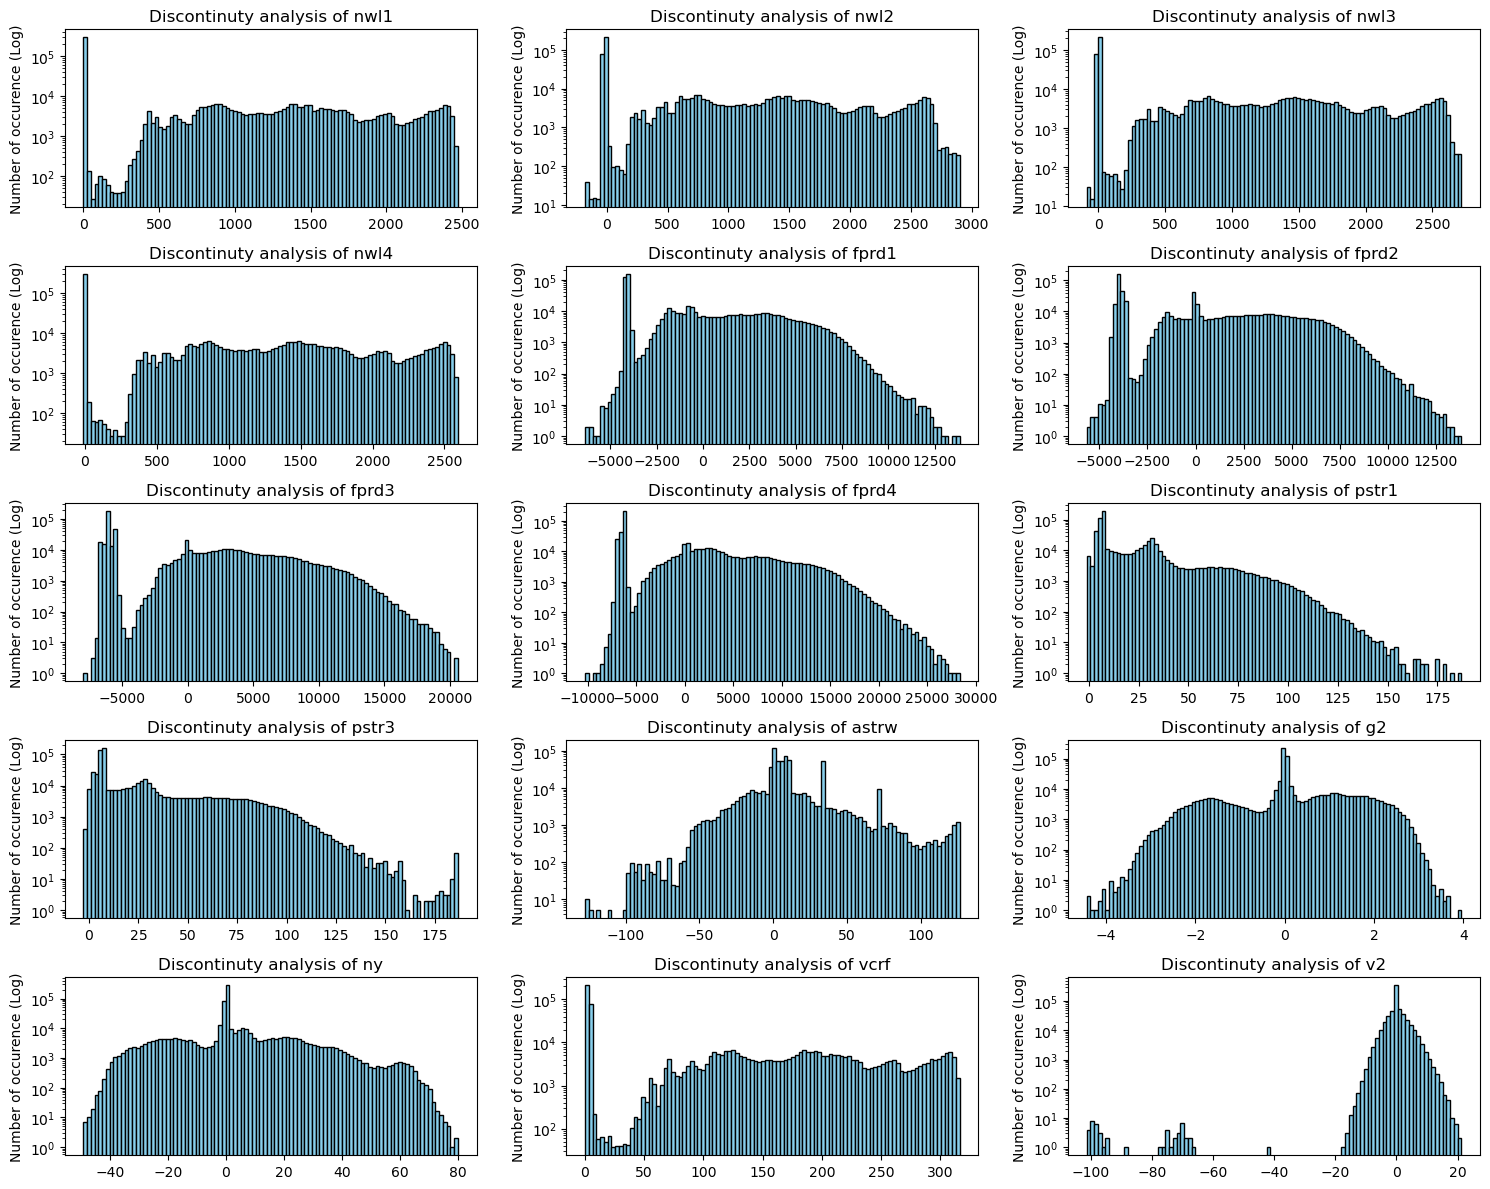

In [5]:
cols = list(df_all.columns[1:-1])
nrows, ncols = 5, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=False)
axes = axes.flatten()
for ax, col in zip(axes, cols[:nrows * ncols]):
    visualisation.plot_hist(df_all, col, ax=ax)
for ax in axes[len(cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

# Affichage en boxplot de toute les variables en fonction de toutes les sesssions

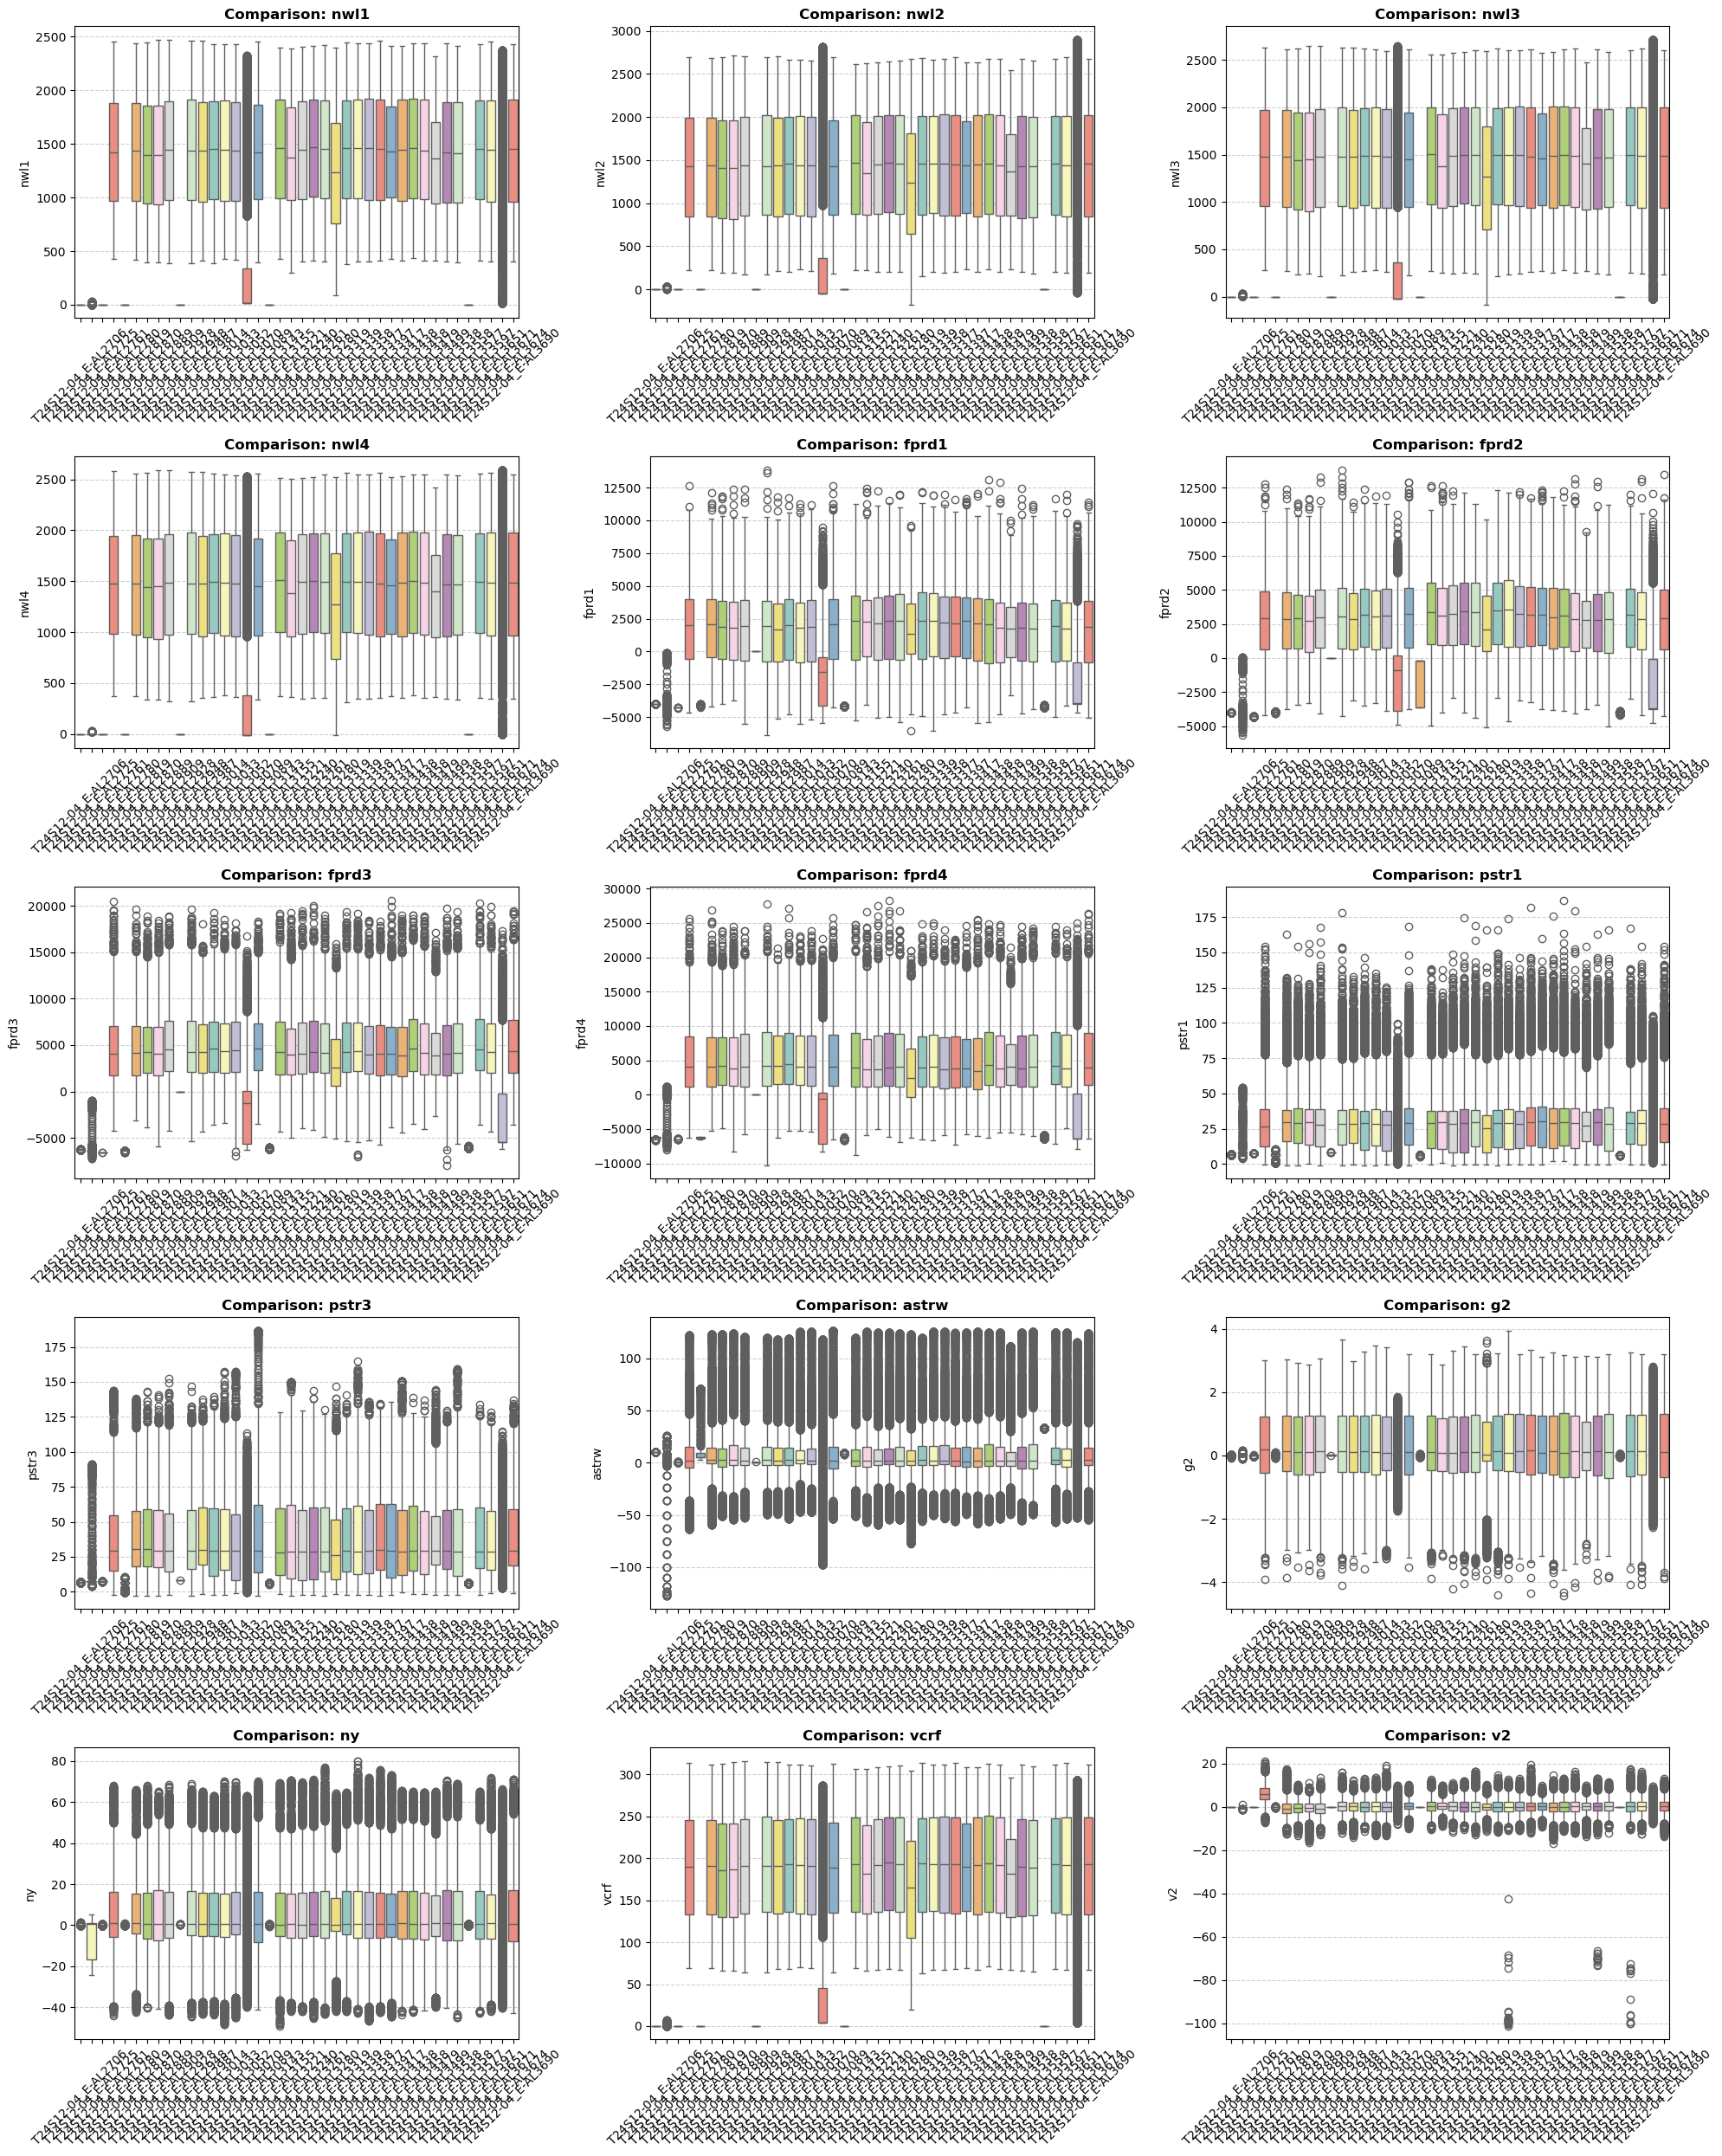

In [6]:

import seaborn as sns

# 1. On liste les colonnes de capteurs (on ignore l'index et session_id)
cols = [c for c in df_all.columns if c not in ['datetime','index', 'session_id', 'time_real']]

# 2. Configuration de la grille (5 lignes, 3 colonnes pour 15 capteurs)
nrows, ncols = 5, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 25))
axes = axes.flatten()

# 3. Boucle de génération des boxplots comparatifs
for i, col in enumerate(cols):
    if i < len(axes):
        # On trace le boxplot : l'axe X compare les sessions
        sns.boxplot(data=df_all, x='session_id', y=col, ax=axes[i], palette="Set3", hue='session_id', legend=False)
        
        axes[i].set_title(f"Comparison: {col}", fontsize=12, fontweight='bold')
        axes[i].tick_params(axis='x', rotation=45) # Rotation pour lire les noms de sessions
        axes[i].set_xlabel("") # On enlève le label X pour ne pas surcharger
        axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# 4. On cache les axes vides si on a moins de 15 capteurs
# for j in range(len(cols), len(axes)):
#     axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Discontinuité temporelle

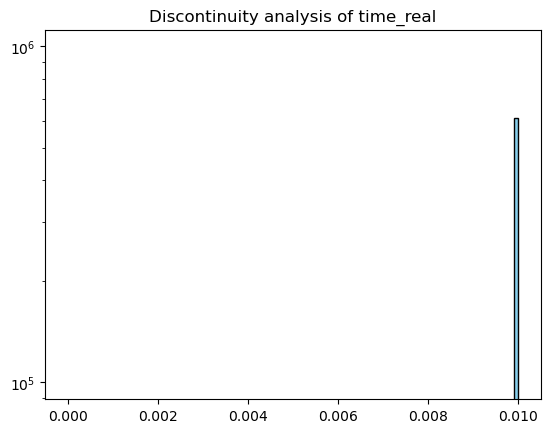

In [7]:
plt.hist(df_all[["time_real"]].diff(), bins=100, color='skyblue', edgecolor='black',range=(0,df_all["time_real"].diff().max()))
plt.yscale("log")
plt.title("Discontinuity analysis of time_real")
plt.show()

Comments: il y a qu'un pic à 0.1 donc il n'y a pas de discontinuité temporelle.

# Filtrage des sessions non-utilisables

In [48]:

# 1. On définit les colonnes de capteurs
cols_to_check = [c for c in df_all.columns if c not in ['datetime','session_id', 'index', 'time_real']]

# 2. Calcul du bruit (l'écart-type) POUR CHAQUE session
session_stds = df_all.groupby('session_id')[cols_to_check].std()

# 3. Référence globale du bruit : Médiane des écarts-types
# (C'est le niveau de bruit "normal" de tes capteurs)
global_stds_ref = session_stds.median()

# 4. Calcul de la dispersion typique du bruit (MAD des écarts-types)
stds_mad = (session_stds - global_stds_ref).abs().median()

# 5. Calcul du score d'écart (Z-score robuste basé sur le bruit)
# On remplace les MAD à 0 par 1 pour éviter la division par zéro
z_scores = (session_stds - global_stds_ref).abs() / stds_mad.replace(0, 1)

# 6. Détection des anomalies (Seuil de sévérité)
seuil_critique = 3
derives_par_capteur = z_scores > seuil_critique

# 7. Règle d'exclusion : On exclut si + de 3 capteurs sont "hors-jeu"
nb_capteurs_en_derive = derives_par_capteur.sum(axis=1)

# /!\ Attention : "<= 3" veut dire qu'on tolère jusqu'à 3 capteurs défaillants. 
# Si tu veux être plus sévère, passe ça à 2 ou 1.
valid_sessions = nb_capteurs_en_derive[nb_capteurs_en_derive <= 5].index
deleted_sessions = nb_capteurs_en_derive[nb_capteurs_en_derive >-1] .index

# 8. Application du filtre
df_filtered = df_all[df_all['session_id'].isin(valid_sessions)].copy()

# --- Diagnostic ---
print(f"--- FILTRAGE ROBUSTE (BASÉ SUR L'ÉCART-TYPE) TERMINÉ ---")
if not deleted_sessions.empty:
    print(f"Sessions exclues : {list(deleted_sessions)}")
    print(f"Détail des dérives par session :\n{nb_capteurs_en_derive[deleted_sessions]}")
else:
    print("Toutes les sessions sont conservées (elles ont un niveau de bruit cohérent).")

# Correction de la variable à la fin (session_stds au lieu de session_medians)
print(f"\n Sessions finales : {len(valid_sessions)} / {len(session_stds)}")

--- FILTRAGE ROBUSTE (BASÉ SUR L'ÉCART-TYPE) TERMINÉ ---
Sessions exclues : ['T24S12-04_E-AL2706', 'T24S12-04_E-AL2725', 'T24S12-04_E-AL2761', 'T24S12-04_E-AL2780', 'T24S12-04_E-AL2819', 'T24S12-04_E-AL2870', 'T24S12-04_E-AL2889', 'T24S12-04_E-AL2909', 'T24S12-04_E-AL2928', 'T24S12-04_E-AL2948', 'T24S12-04_E-AL2987', 'T24S12-04_E-AL3014', 'T24S12-04_E-AL3033', 'T24S12-04_E-AL3052', 'T24S12-04_E-AL3070', 'T24S12-04_E-AL3089', 'T24S12-04_E-AL3143', 'T24S12-04_E-AL3155', 'T24S12-04_E-AL3221', 'T24S12-04_E-AL3240', 'T24S12-04_E-AL3261', 'T24S12-04_E-AL3280', 'T24S12-04_E-AL3319', 'T24S12-04_E-AL3339', 'T24S12-04_E-AL3358', 'T24S12-04_E-AL3377', 'T24S12-04_E-AL3397', 'T24S12-04_E-AL3417', 'T24S12-04_E-AL3438', 'T24S12-04_E-AL3458', 'T24S12-04_E-AL3479', 'T24S12-04_E-AL3499', 'T24S12-04_E-AL3538', 'T24S12-04_E-AL3558', 'T24S12-04_E-AL3577', 'T24S12-04_E-AL3597', 'T24S12-04_E-AL3651', 'T24S12-04_E-AL3671', 'T24S12-04_E-AL3674', 'T24S12-04_E-AL3690']
Détail des dérives par session :
session_id

Comments: Après une inspection visuelle ayant révélé environ 9 sessions défaillantes, grâceà un filtrage statistique basé sur l'écart-type absolu médian (MAD) a été appliqué avec un seuil de $z=2$. Ce filtre a permis d'exclure 11 sessions présentant une instabilité critique sur plusieurs capteurs, garantissant ainsi un jeu de données final de 29 sessions hautement fiables pour l'analyse. Plus précisemment, nous avons enlevé les sessions dont 6 capteurs ou plus étaient défaillant sur les 15 présents.

In [31]:
print(all_paths[34])

c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24\T24S12-04_E-AL3558.csv


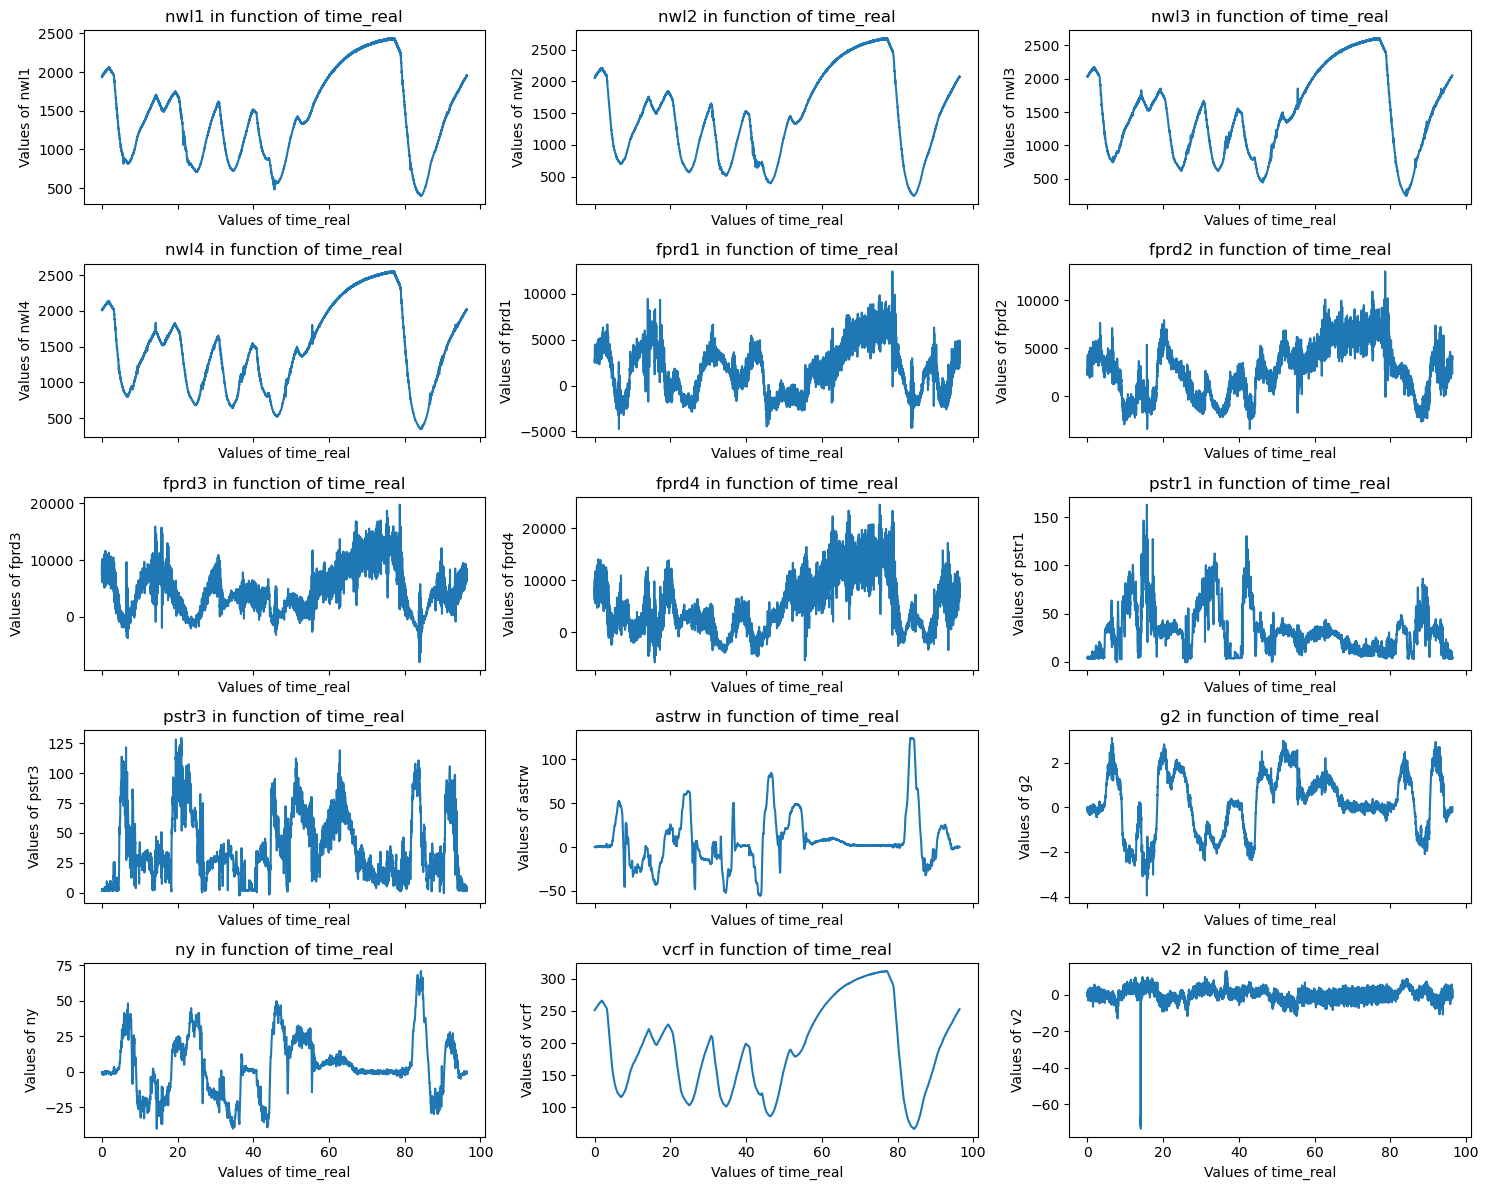

In [38]:

df = data_dict[all_paths[34]]
df_cleaned = preprocessing.clean_dataframe(df.copy())
cols = list(df.columns[1:])
nrows, ncols = 5, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=True)
axes = axes.flatten()
for ax, col in zip(axes, cols[:nrows * ncols]):
    visualisation.plot(df_cleaned, 'time_real', col, ax=ax)
for ax in axes[len(cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

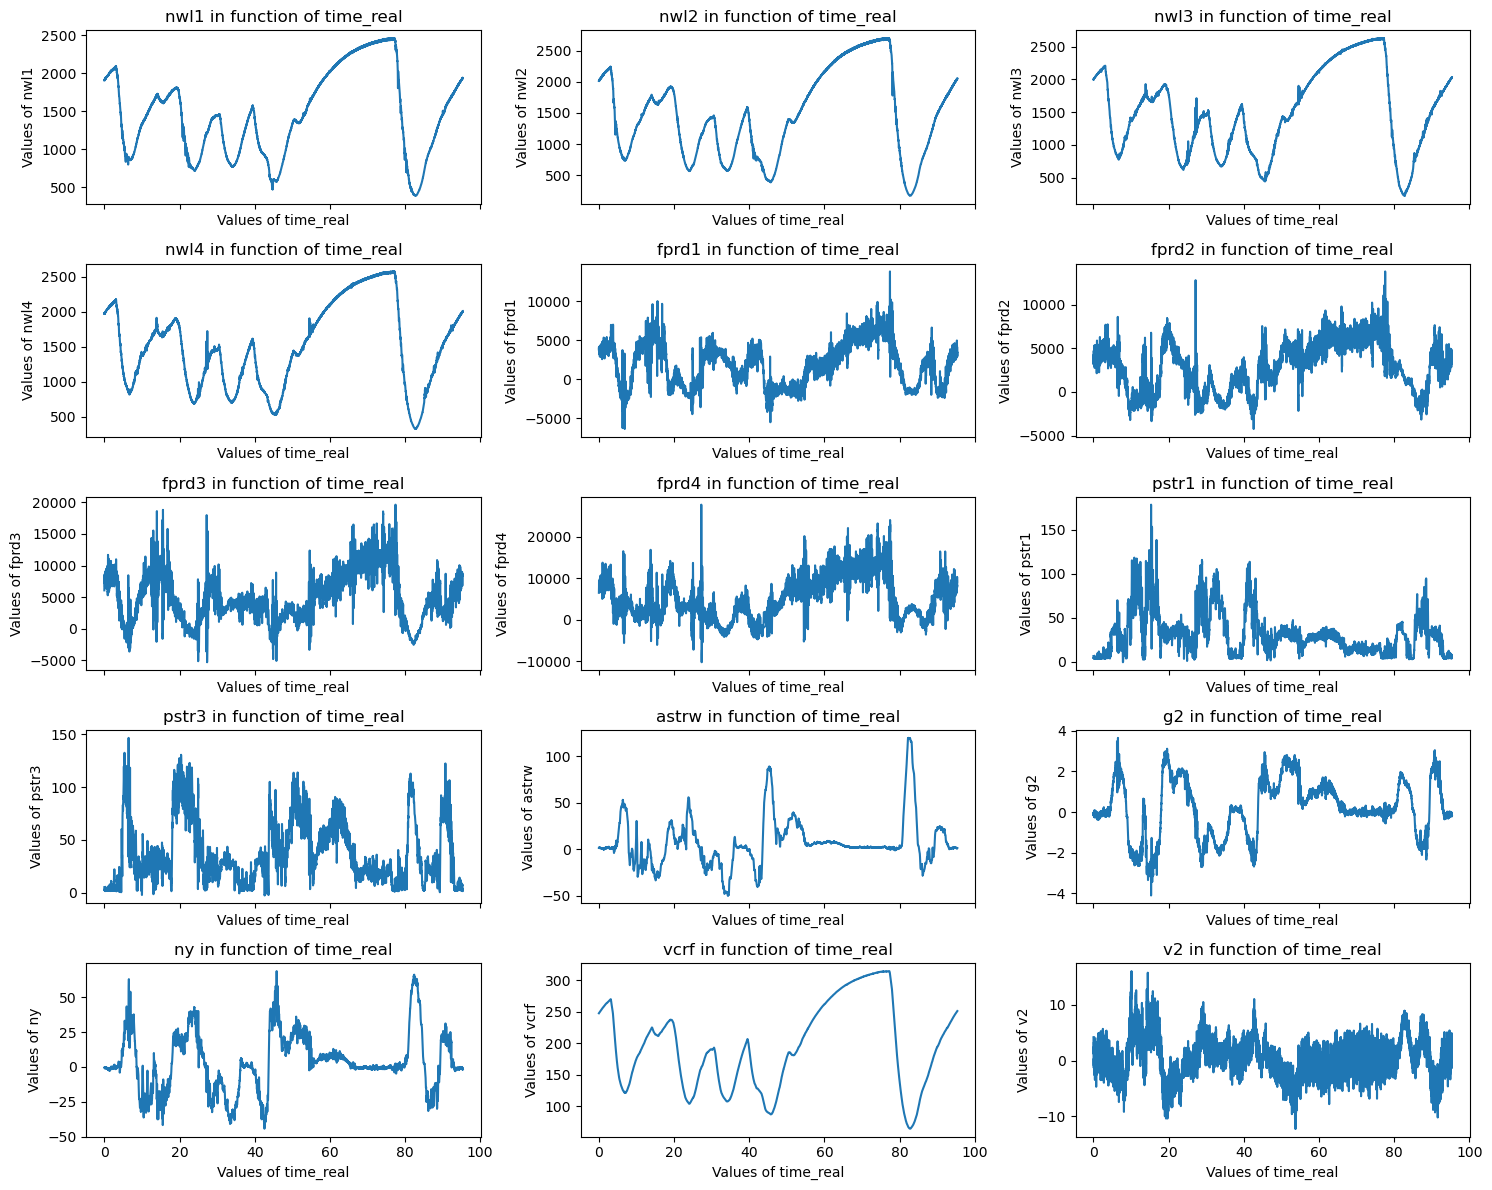

In [45]:
df2 = preprocessing.clean_dataframe(data_dict[all_paths[11]].copy())
cols = list(df.columns[1:])
nrows, ncols = 5, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=True)
axes = axes.flatten()
for ax, col in zip(axes, cols[:nrows * ncols]):
    visualisation.plot(df2, 'time_real', col, ax=ax)
for ax in axes[len(cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

In [10]:

display(df_filtered)
#for name in valid_sessions:
#     cols = list(df.columns[1:-1])
#     nrows, ncols = 5, 3
#     fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=True)
#     axes = axes.flatten()
#     for ax, col in zip(axes, cols[:nrows * ncols]):
#         visualisation.plot(df, 'time_real', col, ax=ax)
#     for ax in axes[len(cols):]:
#         ax.set_visible(False)
#     plt.tight_layout()
#     plt.show()

,datetime,nwl1,nwl2,nwl3,nwl4,fprd1,fprd2,fprd3,fprd4,pstr1,pstr3,astrw,g2,ny,vcrf,v2,time_real,session_id
67080,2024-05-03 19:05:09.479,1907.07,2018.21,1996.95,1970.14,4422.54,4075.89,6260.59,7115.34,4.78839,3.52983,0.636276,0.009091,-0.521420,247.341,7.449030,0.00,T24S12-04_E-AL2780
67081,2024-05-03 19:05:09.489,1907.07,2013.49,2002.41,1975.34,2897.10,3615.71,7652.36,8646.26,4.87162,2.78240,0.215994,-0.121585,-0.883973,247.430,8.360160,0.01,T24S12-04_E-AL2780
67082,2024-05-03 19:05:09.499,1912.77,2018.21,2000.23,1971.18,3840.65,3477.77,8482.17,10067.30,4.55949,2.94489,0.401888,-0.062186,-0.453441,247.430,7.103430,0.02,T24S12-04_E-AL2780
67083,2024-05-03 19:05:09.509,1908.02,2020.57,2003.51,1972.22,4740.16,4735.44,7680.30,8673.72,4.67394,3.19403,0.345311,0.009091,-0.748015,247.518,9.585470,0.03,T24S12-04_E-AL2780
67084,2024-05-03 19:05:09.519,1910.87,2018.21,2004.60,1979.50,2863.49,3576.30,7678.65,8378.51,4.95486,2.56576,0.312982,-0.133464,-0.951951,247.607,11.219200,0.04,T24S12-04_E-AL2780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612460,2024-04-09 16:37:55.315,1941.59,2048.39,2035.99,2000.11,3719.91,4061.02,8024.95,7322.66,6.99120,5.85707,1.760540,-0.191725,-0.735798,251.164,0.685691,95.15,T24S12-04_E-AL3690
612461,2024-04-09 16:37:55.325,1939.69,2054.29,2030.52,2005.31,4340.05,4175.77,7702.88,9025.20,4.76465,5.60793,1.590810,-0.132327,-0.735798,251.253,1.565400,95.16,T24S12-04_E-AL3690
612462,2024-04-09 16:37:55.335,1940.64,2060.19,2031.61,2001.15,4331.93,4648.70,8151.47,9155.63,6.62705,6.68032,1.372590,-0.251123,-0.815106,251.430,-2.204790,95.17,T24S12-04_E-AL3690
612463,2024-04-09 16:37:55.345,1942.54,2050.75,2039.26,2004.27,3632.97,4354.28,8744.66,9583.57,5.14961,3.60395,1.550400,-0.227364,-0.883085,251.518,-1.356500,95.18,T24S12-04_E-AL3690


# Correlation matrix 

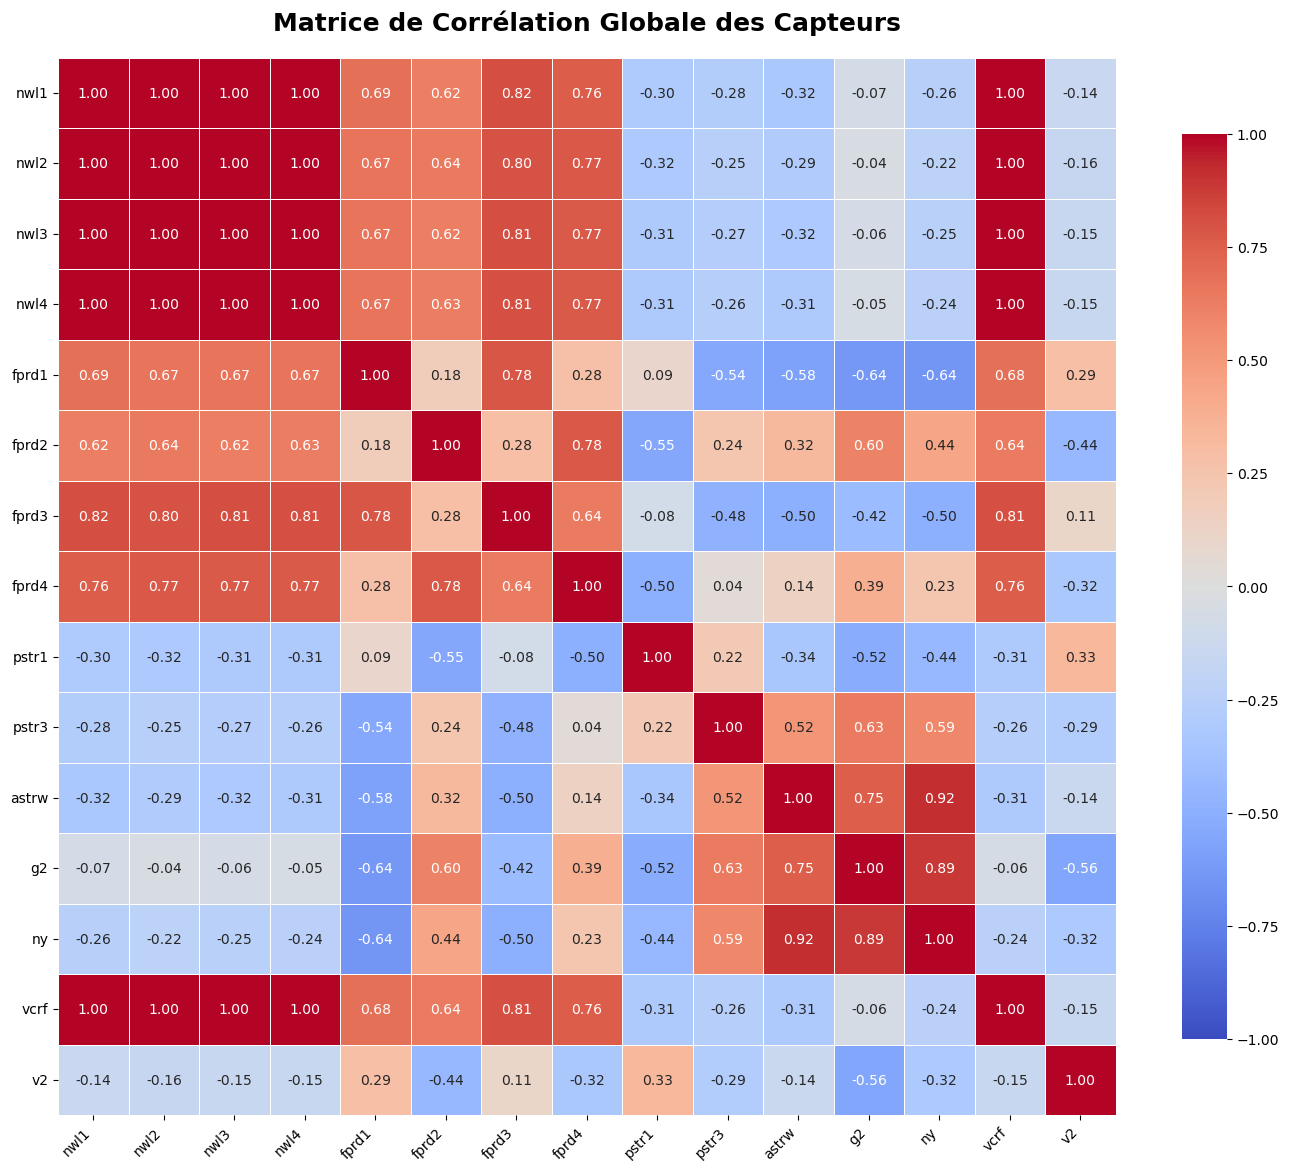

In [11]:

# 1. On sélectionne uniquement les colonnes numériques des capteurs
# (On exclut le temps et les identifiants pour ne pas fausser le calcul)
cols_capteurs = [c for c in df_filtered.columns if c not in ['session_id', 'index', 'time_real', 'datetime']]

# 2. On calcule la matrice de corrélation de Pearson (linéaire)
corr_matrix = df_filtered[cols_capteurs].corr()

# 3. Préparation de la figure
plt.figure(figsize=(14, 12))

# Astuce Pro : Créer un "masque" pour cacher la moitié supérieure du tableau
# (Puisque la corrélation A vs B est la même que B vs A, ça allège la lecture)
#mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Tracé de la Heatmap avec Seaborn
sns.heatmap(corr_matrix,  
            annot=True,              # Affiche les chiffres dans les cases
            fmt=".2f",               # Arrondi à 2 chiffres après la virgule
            cmap="coolwarm",         # Palette de couleurs (Bleu = négatif, Rouge = positif)
            vmin=-1, vmax=1,         # L'échelle va toujours de -1 à 1
            square=True,             # Rend les cases bien carrées
            linewidths=.5,           # Petit liseré entre les cases
            cbar_kws={"shrink": .8}) # Réduit un peu la taille de la barre de légende

plt.title("Matrice de Corrélation Globale des Capteurs", fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Matrice session par session

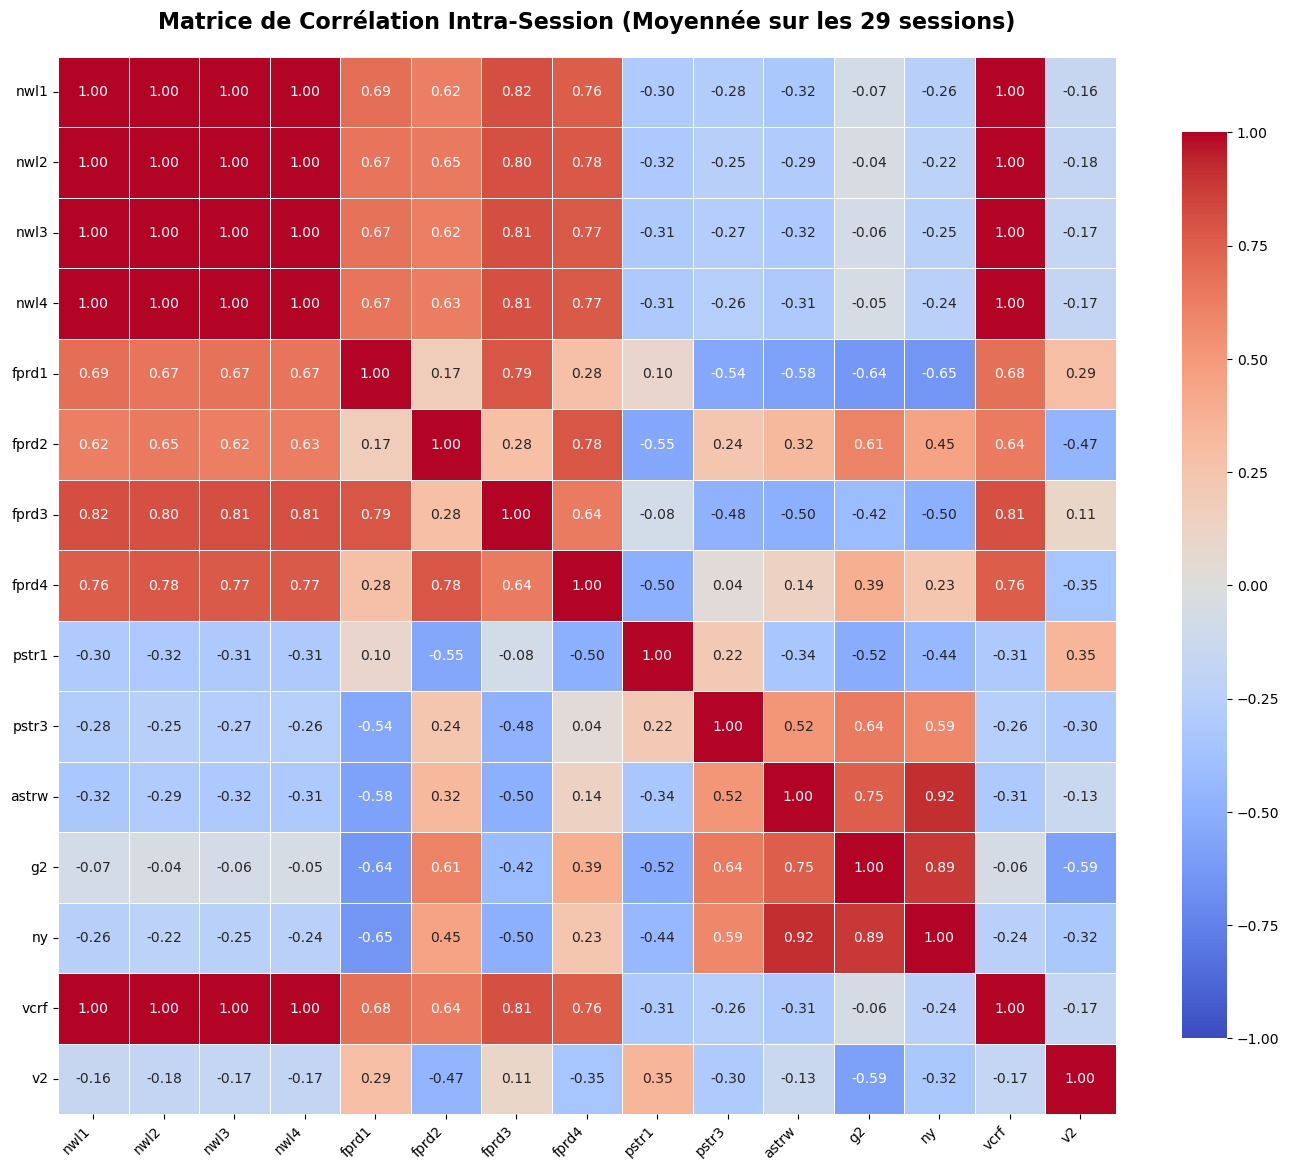

In [12]:

# 1. On crée une liste pour stocker la matrice de chaque session
toutes_les_matrices = []

# 2. On boucle sur chaque session proprement
for session_name, df_session in df_filtered.groupby('session_id'):
    # On calcule la corrélation UNIQUEMENT pour cette session
    corr_session = df_session[cols_capteurs].corr()
    toutes_les_matrices.append(corr_session)

# 3. On calcule la "Matrice Moyenne" de toutes les sessions
# (On additionne toutes les matrices et on divise par le nombre de sessions)
corr_matrix_moyenne = sum(toutes_les_matrices) / len(toutes_les_matrices)

# 4. Tracé de la Heatmap rigoureuse
plt.figure(figsize=(14, 12))


sns.heatmap(corr_matrix_moyenne,  
            annot=True,              
            fmt=".2f",               
            cmap="coolwarm",         
            vmin=-1, vmax=1,         
            square=True,             
            linewidths=.5,           
            cbar_kws={"shrink": .8}) 

plt.title("Matrice de Corrélation Intra-Session (Moyennée sur les 29 sessions)", 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
value=abs(corr_matrix-corr_matrix_moyenne)
value.max().max()

0.030501906553624003

On remarque que la différence entre la matrice de corrélation moyenne et celle avec la matrice où l'on a concaténé toutes les sessions sont sensiblement les mêmes (plus grand écart de $0.03$).


En terme de corrélation positive:
- On peut conclure que les variables nwl1,nwl2,nwl3,nwl4 sont extrèmement corrélées, ce qui est physiquement logique car cela correspond aux capteurs d'angle des 4 roues.
- De plus, on voit que les variables fprd sont corrélé deux à deux, surement sur les roues opposés sur la voiture. C'est cohérent, la force appliquée à une roue est lié à celle qui lui est opposée.
- Aussi on voit que la force sur les axes (fprd)est fortement corrélée (plus de $0.60$) à l'angle des roues (nwl), en effet plus l'angle de rotation est élevé plus la force sur les roues est importante.
- On remarque que la vitesse de la voiture (vcrf) est très corrélée ($1$) avec les variables nwl et fprd.
- la variable ny est pstr3,astrw, g2 


En terme de corrélation négative:
- la pression avant (pstr1) est corrélé avec la force sur les roues arrière (2,4). De même pour, la pression arrière (pstr3) est la force sur les roues avant (1,3).
- l'angle du volant (astrw),accélération latérale(g2) et angle lacet (ny) sont aussi corrélés avec fprd1 et fprd3.
- les variables g2 et v2. En effet la vitesse et l'accélération sont relié( l'accélération est la dérivé de la vitesse).


# Création du comportement moyen

In [14]:


def plot_reference_profile(df, sensor_name, time_col='time_real', session_col='session_id'):
    """
    Génère le profil de référence d'un capteur (moyenne + enveloppe d'écart-type)
    en superposant toutes les sessions.
    """
    # 1. On isole juste ce dont on a besoin pour calculer proprement
    df_temp = df[[session_col, time_col, sensor_name]].copy()
    
    # On arrondit le temps à 2 décimales (100 Hz) pour aligner mathématiquement les points
    df_temp['time_rounded'] = df_temp[time_col].round(2)

    # 2. Calcul de la moyenne et de l'écart-type pour chaque instant 't'
    stats_temp = df_temp.groupby('time_rounded')[sensor_name].agg(['mean', 'std']).reset_index()

    # 3. Préparation du graphique
    plt.figure(figsize=(12, 6))

    # --- Les données brutes (en gris clair) ---
    for session, df_session in df_temp.groupby(session_col):
        plt.plot(df_session['time_rounded'], df_session[sensor_name], 
                 color='gray', alpha=0.15, linewidth=1)

    # --- Le profil idéal (Moyenne en rouge) ---
    plt.plot(stats_temp['time_rounded'], stats_temp['mean'], 
             color='red', linewidth=2.5, label='Comportement Moyen')

    # --- L'enveloppe de tolérance (Zone rouge claire) ---
    # fill_between colorie l'espace entre la borne basse et la borne haute
    plt.fill_between(stats_temp['time_rounded'], 
                     stats_temp['mean'] - stats_temp['std'], 
                     stats_temp['mean'] + stats_temp['std'], 
                     color='red', alpha=0.3, label='Tolérance (± 1 Écart-Type)')

    # 4. Habillage professionnel
    plt.title(f"Profil de Référence - Capteur : {sensor_name}", fontsize=15, fontweight='bold')
    plt.xlabel("Temps (s)", fontsize=12)
    plt.ylabel(f"Valeur de {sensor_name}", fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xlim(left=0)
    
    plt.tight_layout()
    plt.show()

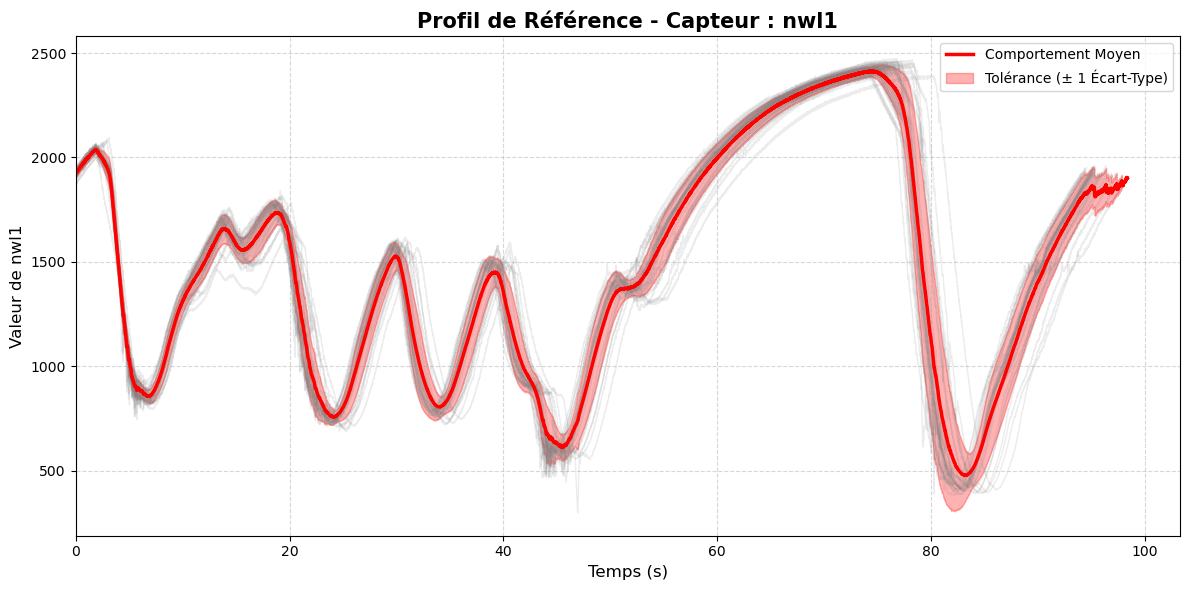

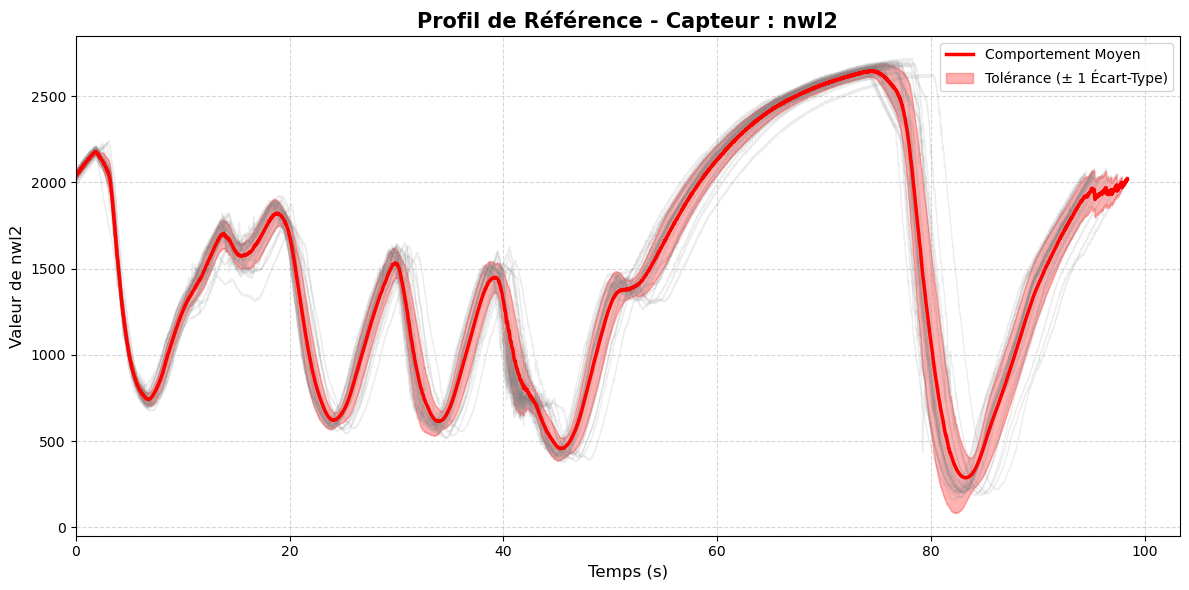

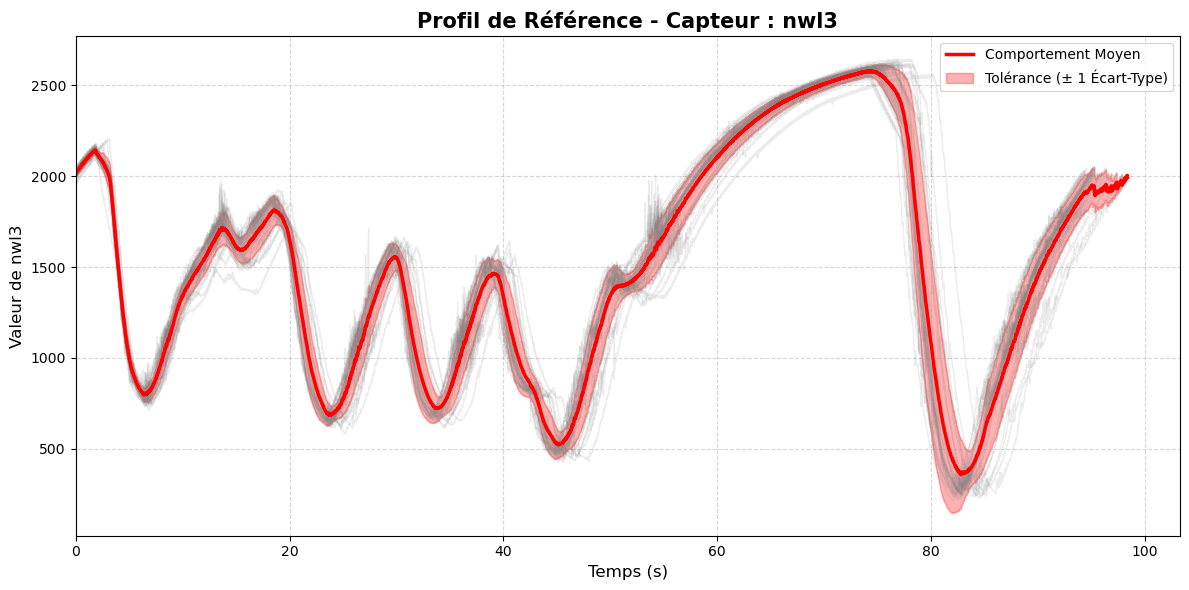

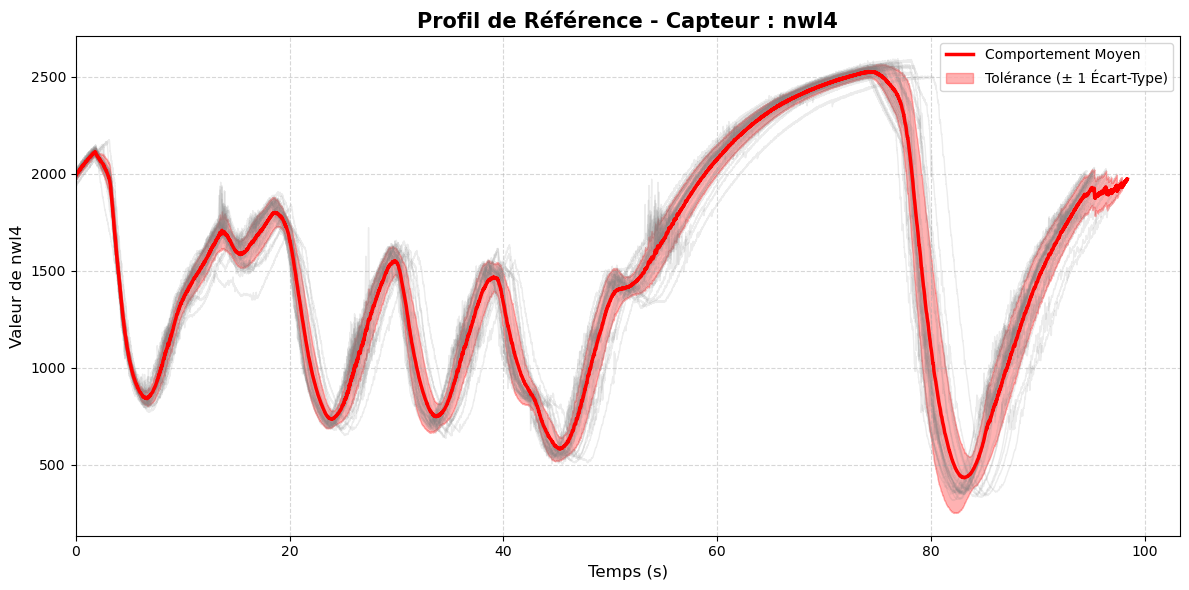

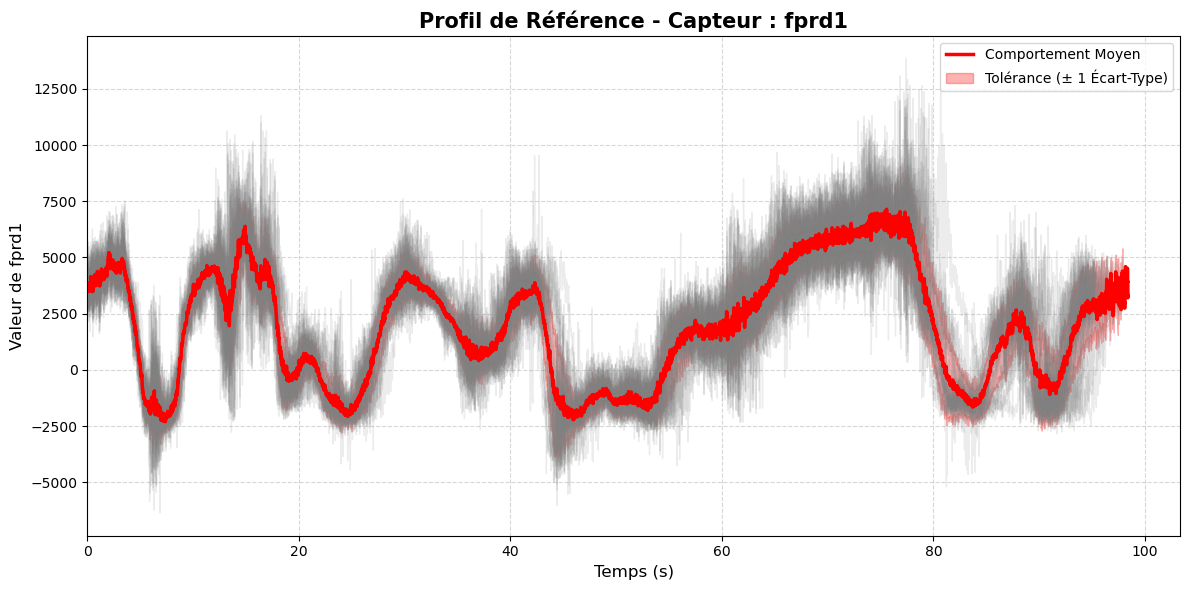

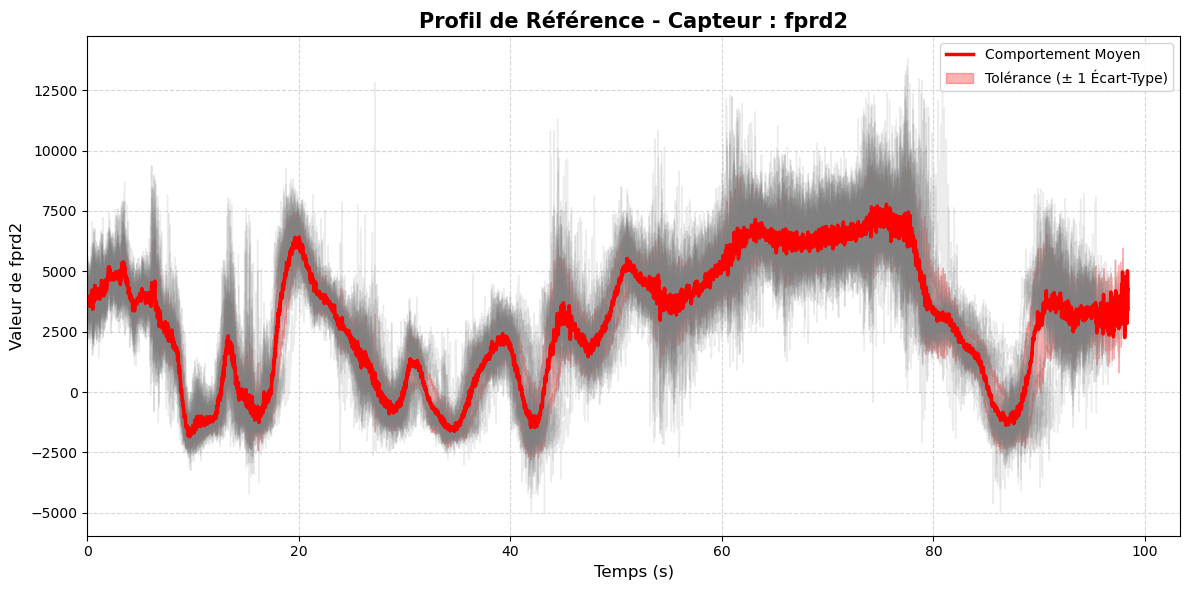

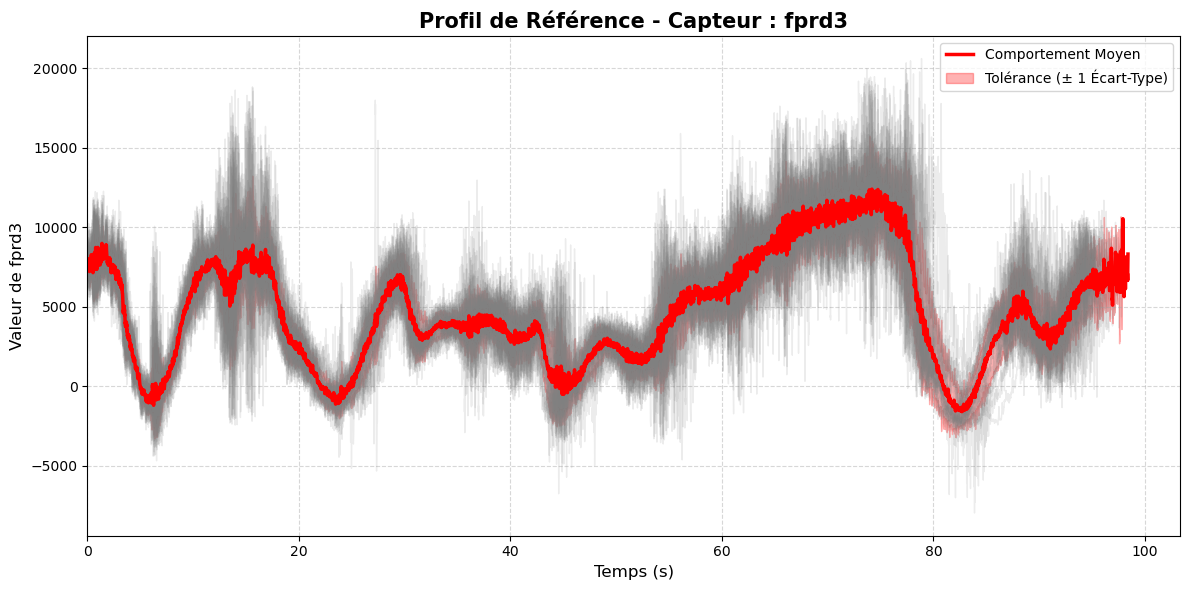

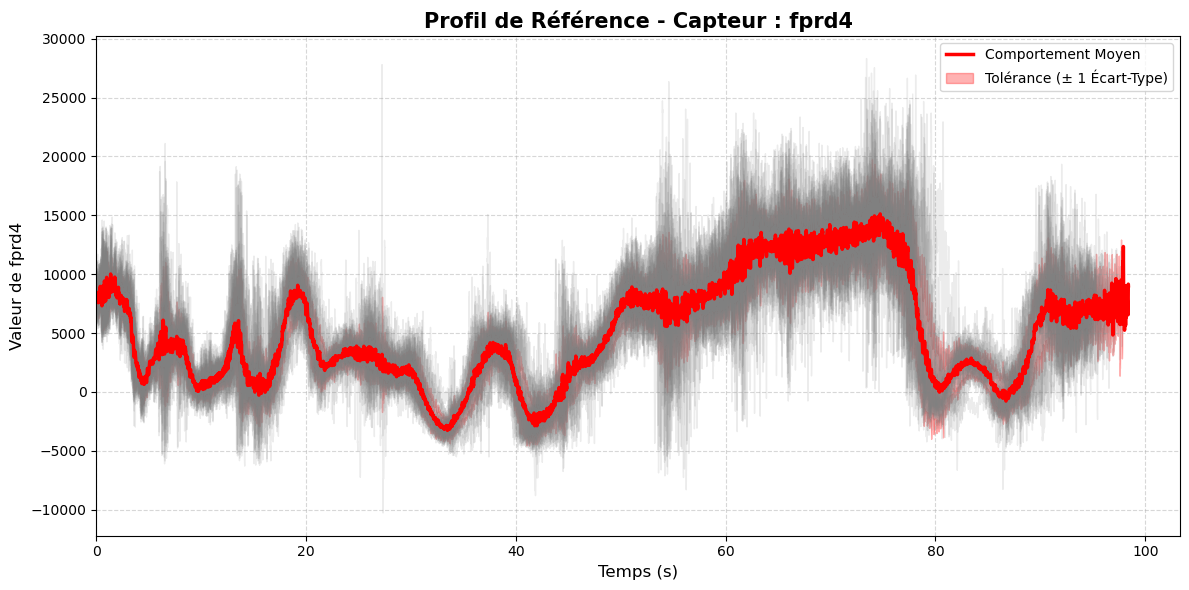

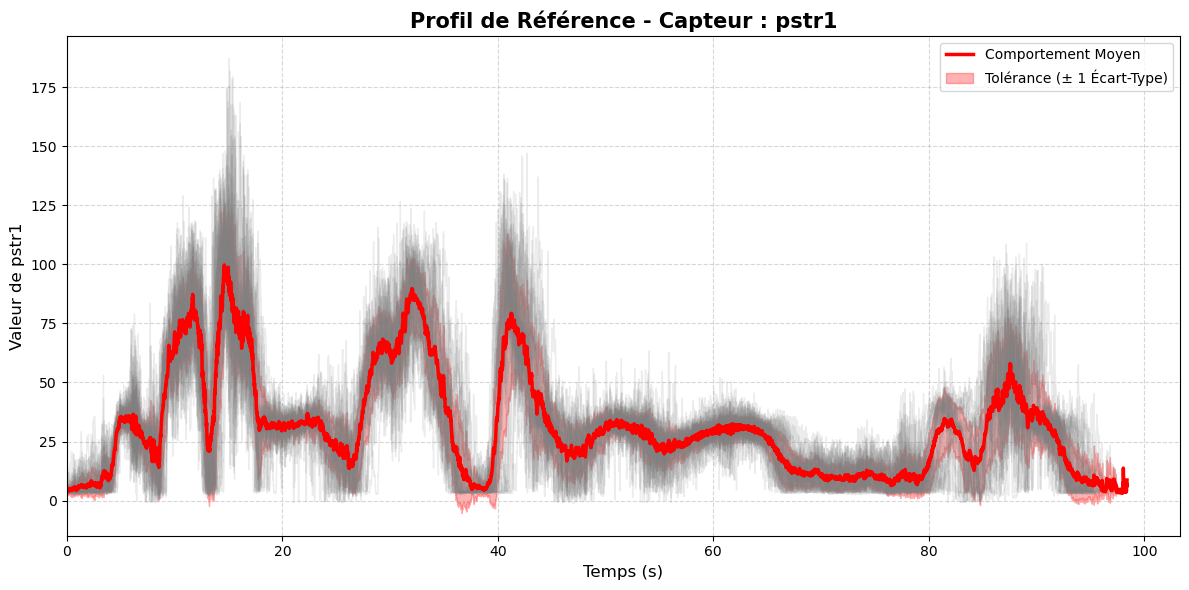

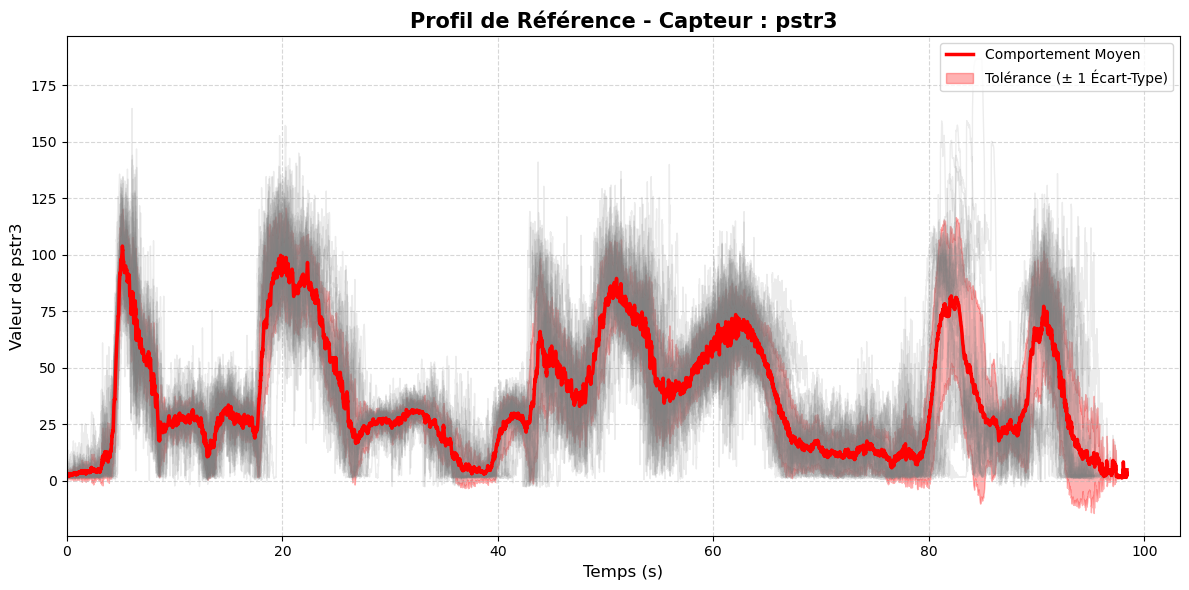

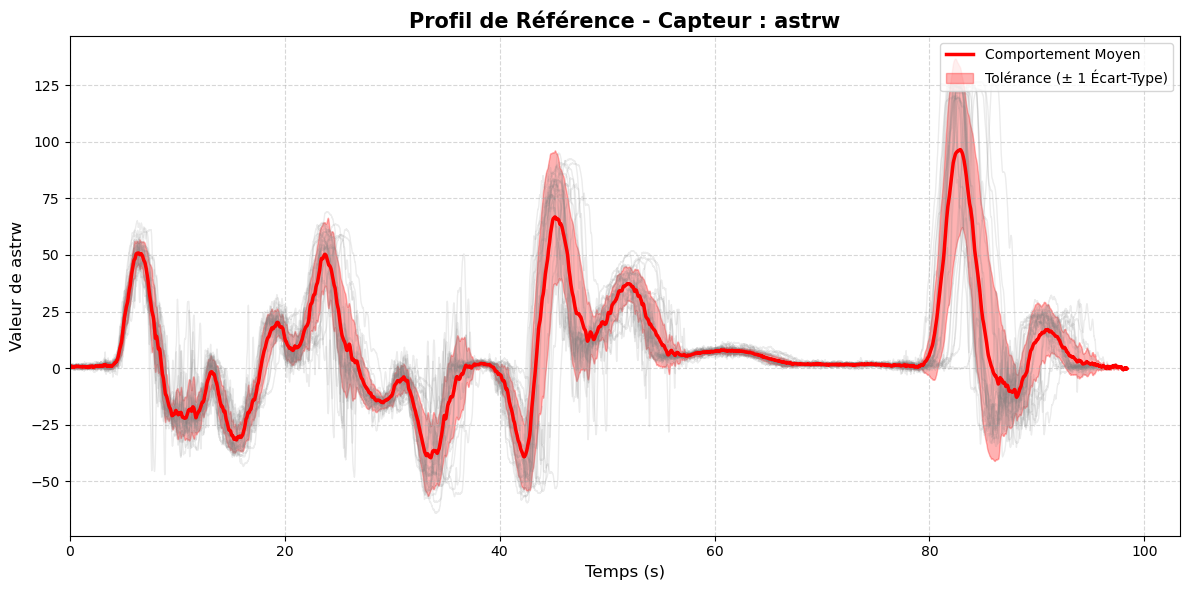

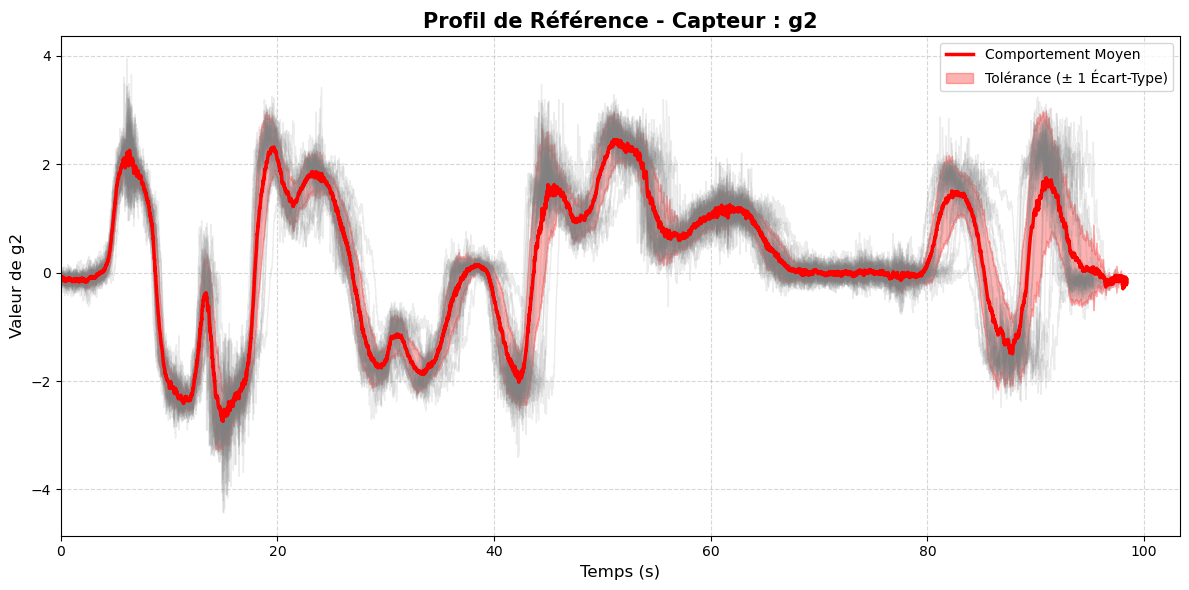

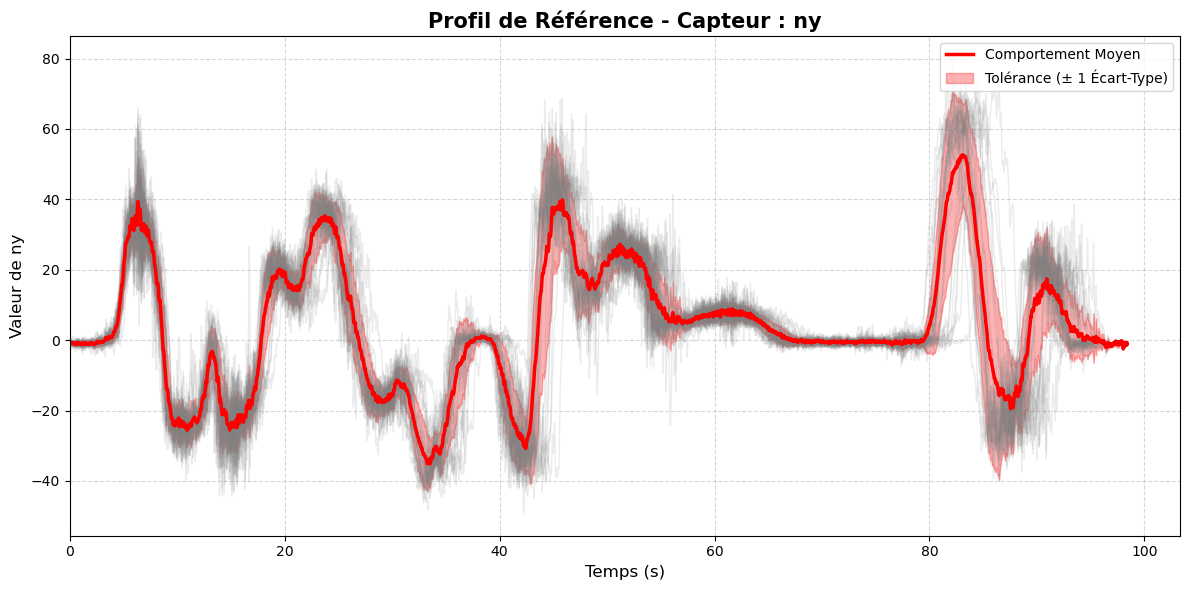

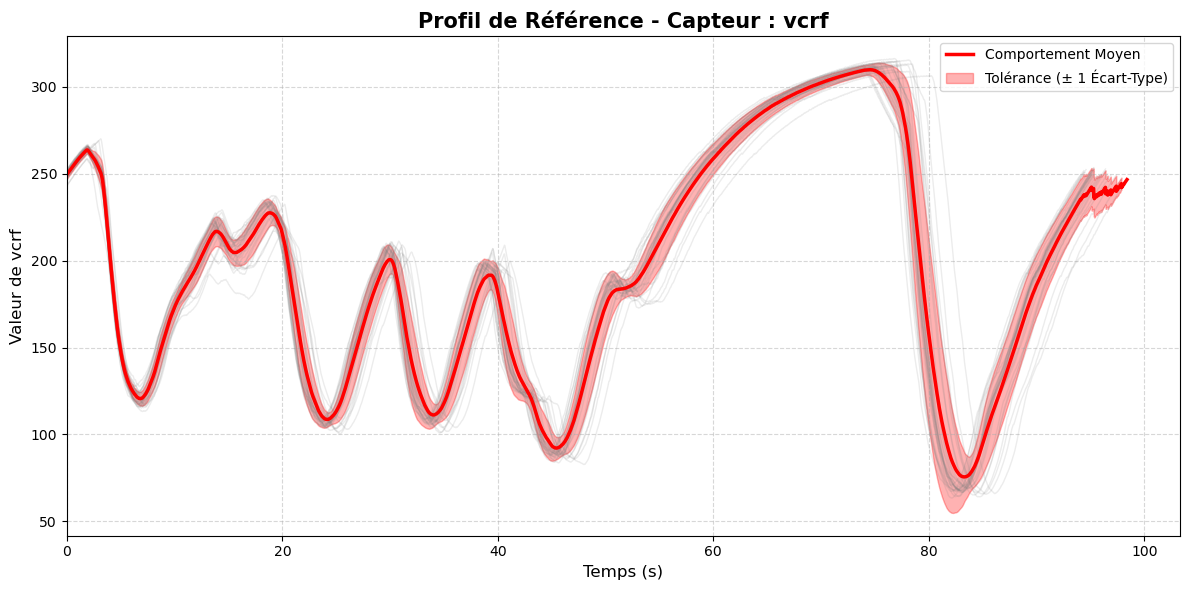

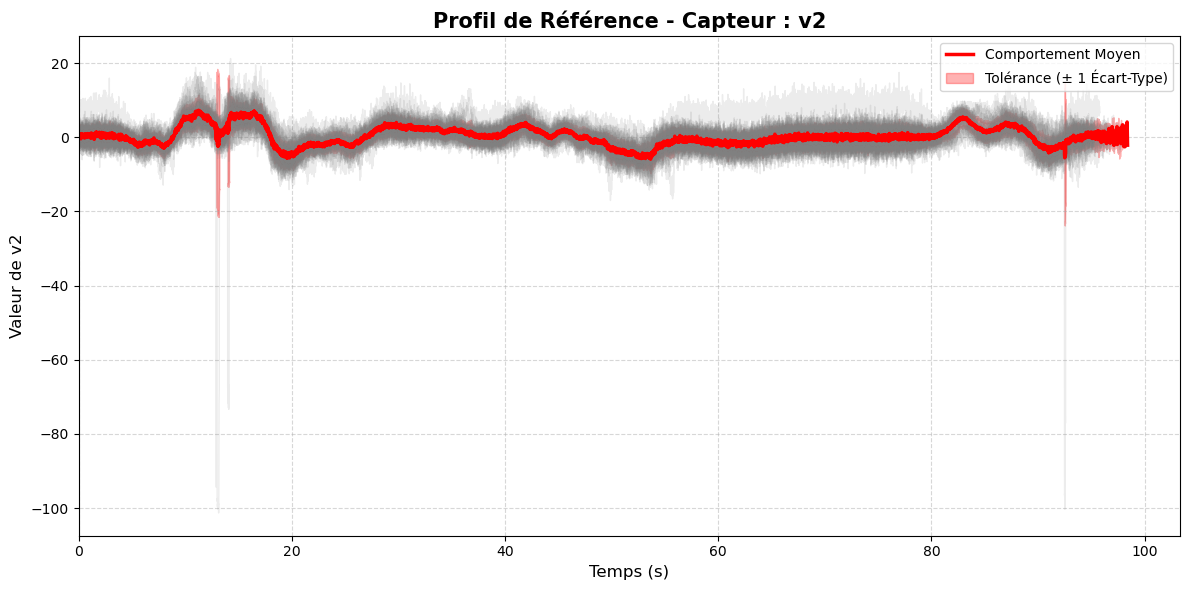

In [15]:
for name in cols_capteurs:
    plot_reference_profile(df_filtered, name, time_col='time_real', session_col='session_id')

on se rend compte que les capteurs: fprd1 à fprd4, ny, g2,pstr1 et pstr3 nécessiteront un traitement du bruit car  on voit que le profil moyen est très bruité.

# On enregistre les données pour l'utiliser dans un autre notebook

In [9]:
# 1. On nettoie l'index (on oublie les anciens numéros de lignes de df_all)
df_filtered = df_filtered.reset_index(drop=True)

# 2. On tente la sauvegarde en forçant le moteur 'fastparquet'
try:
    df_filtered.to_parquet('dataset_propre_insa.parquet', engine='fastparquet', index=False)
    print(" Sauvegardé en Parquet avec succès !")
except Exception as e:
    print(f"Erreur persistante : {e}")

 Sauvegardé en Parquet avec succès !
